# Real Life vs Potential Analysis

## Data

In [27]:
## Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from rapidfuzz import fuzz
from rapidfuzz import process
# Reset display options to default, then change again
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [28]:
## Load Dataset
ea = pd.read_csv(r'C:\Users\al3xd\Downloads\EA\male_players.csv')
stats = pd.read_csv(r'C:\Users\al3xd\Downloads\EA\2022-23-Stats.csv')

C:\Users\al3xd\AppData\Local\Temp\ipykernel_41252\2683590744.py:2: DtypeWarning: Columns (0: gk) have mixed types. Specify dtype option on import or set low_memory=False.
  ea = pd.read_csv(r'C:\Users\al3xd\Downloads\EA\male_players.csv')


In [29]:
## Load Dataset
stats = stats.copy()
ea_sports = ea.copy()

In [30]:
def info(data):
    df_info = pd.DataFrame({
        'Non-Null Count': data.notnull().sum(),
        'Data Type': data.dtypes
    })
    print(df_info)
    return df_info

In [31]:
stats_info = info(stats)
ea_info = info(ea_sports)
print(stats_info)
print(ea_info)

                               Non-Null Count Data Type
Squad                                    3317       str
Comp                                     3317       str
Player                                   3317       str
Nation                                   3313       str
Pos                                      3317       str
Age                                      3317     int64
Born                                     3317     int64
MP                                       3317     int64
Minutes_Played                           2703   float64
Mn_per_MP                                2703   float64
Mins_Per_90                              2705   float64
Starts                                   3317     int64
PPM_Team.Success                         2705   float64
onG_Team.Success                         2705   float64
onGA_Team.Success                        2705   float64
plus_per__minus__Team.Success            2705   float64
Goals                                    2721   

In [32]:
stats.head()

,Squad,Comp,Player,Nation,Pos,Age,Born,MP,Minutes_Played,Mn_per_MP,Mins_Per_90,Starts,PPM_Team.Success,onG_Team.Success,onGA_Team.Success,plus_per__minus__Team.Success,Goals,Assists,GoalsAssistsCombined,NonPKG,PK,PKatt,CrdY,CrdR,xG,xAG,npxG+xAG,PrgC,PrgP,Gls_Per90,Ast_Per90,G+A_Per90,G_minus_PK_Per,G+A_minus_PK_Per,xG_Per,xAG_Per,xG+xAG_Per,Shots,Shots_on_Target,SoT_percent,G_per_Sh,G_per_SoT,Avg_Shot_Dist,FK_Standard,G_minus_xG_Expected,np:G_minus_xG_Expected,Passes_Completed,Passes_Attempted,Passes_Cmp_percent,PrgDist_Total,Passes_Cmp_Short,Passes_Att_Short,Passes_Cmp_percent_Short,Passes_Cmp_Medium,Passes_Att_Medium,Passes_Cmp_percent_Medium,Passes_Cmp_Long,Passes_Att_Long,Passes_Cmp_percent_Long,xA_Expected,A_minus_xAG_Expected,Key_Passes,Final_Third,PPA,CrsPA,TB_Pass,Crs_Pass,Offside_Passes,Blocked_Passes,Shot_Creating_Actions,SCA_90,TakeOnTo_Shot,FoulTo_Shot,DefAction_Shot,GoalCreatingAction,GCA90,TakeOn_Goal,Fld_Goal,DefAction_Goal,Tackles,Tackles_Won,Def_3rd_Tackles,Mid_3rd_Tackles,Att_3rd_Tackles,Tkl_percent_won,Lost_Challenges,Blocks,Sh_Blocked,Passes_Blocked,Interceptions,Clearances,ErrorsLead_ToShot,Att_Take,Succ_Take,Succ_percent_Take,Tkld_Take,Tkld_percent_Take,TotDist_Carries,PrgDist_Carries,Miscontrolls,Dispossessed,2CrdY,Fouls_Comitted,Fouls_Drawn,Offsides,Crosses,PK_Won,PK_Conceded,Own_Goals,Loose_Ball_Recoveries,Won_Aerial,Lost_Aerial,Won_percent_Aerial,Goals_Against_GK,SoT_Against_GK,Saves_GK,Save_percent_GK,Clean_Sheets_GK,CS_percent_GK,PK_Faced_GK,PK_Allowed_GK,PK_Saved_GK,PK_Missed_GK,Save_percent_Penalty_GK,FK_Goals_GK,CornerKick_Goals_GK,OG_GK,PSxG_GK,PSxG_per_SoT_GK,PSxG+_per_minus_GK,LaunchedPassesCompleted_GK,LaunchedAttempted_GK,Cmp_percent_Launched_GK,Att_Passes_GK,Throws_GK,Launch_percent_Passes_GK,AvgLen_Passes_GK,Att_Goal_Kicks_GK,AvgLen_GoalKick_GK,CrossesFaced_GK,CrossedStopped_GK,CrossedStopped_Perc_GK,OPA_Sweeper_GK,OPA_per_90_Sweeper_GK,AvgDist_Sweeper_GK
0,Ajaccio,Ligue 1,Mickaël Alphonse,GLP,DF,33,1989,26,1361.0,52.0,15.1,14,0.73,7.0,30.0,-23.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.5,0.7,1.2,30.0,51.0,0.00,0.00,0.00,0.00,0.00,0.03,0.04,0.08,10.0,2.0,20.0,0.00,0.00,16.3,0.0,-0.5,-0.5,448.0,686.0,65.3,3413.0,197.0,237.0,83.1,190.0,272.0,69.9,45.0,133.0,33.8,0.9,-0.7,11.0,43.0,10.0,5.0,0.0,27.0,2.0,21.0,19.0,1.25,1.0,0.0,1.0,0.0,0.00,0.0,0.0,0.0,35.0,23.0,20.0,11.0,4.0,60.6,13.0,17.0,5.0,12.0,35.0,44.0,1.0,19.0,10.0,52.6,8.0,42.1,2988.0,1528.0,15.0,14.0,0.0,19.0,15.0,0.0,27.0,0.0,1.0,1.0,89.0,32.0,27.0,54.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ajaccio,Ligue 1,Cédric Avinel,GLP,DF,35,1986,24,1794.0,75.0,19.9,19,0.63,11.0,40.0,-29.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,3.0,31.0,0.05,0.00,0.05,0.05,0.05,0.05,0.00,0.05,3.0,1.0,33.3,0.33,1.00,4.1,0.0,0.0,0.0,607.0,714.0,85.0,4107.0,174.0,194.0,89.7,346.0,388.0,89.2,71.0,108.0,65.7,0.1,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.15,0.0,0.0,0.0,1.0,0.05,0.0,0.0,0.0,13.0,7.0,8.0,5.0,0.0,66.7,4.0,20.0,13.0,7.0,15.0,91.0,1.0,1.0,0.0,0.0,0.0,0.0,3235.0,1495.0,3.0,0.0,0.0,12.0,2.0,0.0,0.0,0.0,2.0,0.0,93.0,38.0,15.0,71.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ajaccio,Ligue 1,Mickaël Barreto,FRA,MF,31,1991,20,1325.0,66.0,14.7,15,0.60,6.0,34.0,-28.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.9,1.9,2.8,26.0,87.0,0.07,0.07,0.14,0.07,0.14,0.06,0.13,0.19,19.0,4.0,21.1,0.05,0.25,26.6,3.0,0.1,0.1,481.0,695.0,69.2,3373.0,205.0,247.0,83.0,179.0,239.0,74.9,80.0,173.0,46.2,2.1,-0.9,18.0,71.0,16.0,7.0,2.0,76.0,5.0,14.0,30.0,2.04,0.0,0.0,1.0,1.0,0.07,0.0,0.0,0.0,32.0,20.0,12.0,17.0,3.0,17.8,37.0,17.0,0.0,17.0,18.0,11.0,0.0,49.0,23.0,46.9,24.0,49.0,3671.0,1576.0,34.0,19.0,0.0,20.0,8.0,0.0,76.0,0.0,0.0,0.0,100.0,9.0,7.0,56.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ajaccio,Ligue 1,Cyrille Bayala,BFA,MF,26,19

In [33]:
ea_sports.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical fin...","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, ...","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Cro...","Pinged Pass +, Dead Ball, Incisive Pass, Long ...",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acroba...","Technical +, Finesse Shot, Dead Ball, Pinged P...",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,75,96.0,20,35,24,6,11,15,14,8,NaN,85+3,85+3,85+3,90,89,89,89,90,91-1,91-1,91-1,89+1,85+3,85+3,85+3,89+1,64+3,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,

In [34]:
stats.describe()

,Age,Born,MP,Minutes_Played,Mn_per_MP,Mins_Per_90,Starts,PPM_Team.Success,onG_Team.Success,onGA_Team.Success,plus_per__minus__Team.Success,Goals,Assists,GoalsAssistsCombined,NonPKG,PK,PKatt,CrdY,CrdR,xG,xAG,npxG+xAG,PrgC,PrgP,Gls_Per90,Ast_Per90,G+A_Per90,G_minus_PK_Per,G+A_minus_PK_Per,xG_Per,xAG_Per,xG+xAG_Per,Shots,Shots_on_Target,SoT_percent,G_per_Sh,G_per_SoT,Avg_Shot_Dist,FK_Standard,G_minus_xG_Expected,np:G_minus_xG_Expected,Passes_Completed,Passes_Attempted,Passes_Cmp_percent,PrgDist_Total,Passes_Cmp_Short,Passes_Att_Short,Passes_Cmp_percent_Short,Passes_Cmp_Medium,Passes_Att_Medium,Passes_Cmp_percent_Medium,Passes_Cmp_Long,Passes_Att_Long,Passes_Cmp_percent_Long,xA_Expected,A_minus_xAG_Expected,Key_Passes,Final_Third,PPA,CrsPA,TB_Pass,Crs_Pass,Offside_Passes,Blocked_Passes,Shot_Creating_Actions,SCA_90,TakeOnTo_Shot,FoulTo_Shot,DefAction_Shot,GoalCreatingAction,GCA90,TakeOn_Goal,Fld_Goal,DefAction_Goal,Tackles,Tackles_Won,Def_3rd_Tackles,Mid_3rd_Tackles,Att_3rd_Tackles,Tkl_percent_won,Lost_Challenges,Blocks,Sh_Blocked,Passes_Blocked,Interceptions,Clearances,ErrorsLead_ToShot,Att_Take,Succ_Take,Succ_percent_Take,Tkld_Take,Tkld_percent_Take,TotDist_Carries,PrgDist_Carries,Miscontrolls,Dispossessed,2CrdY,Fouls_Comitted,Fouls_Drawn,Offsides,Crosses,PK_Won,PK_Conceded,Own_Goals,Loose_Ball_Recoveries,Won_Aerial,Lost_Aerial,Won_percent_Aerial,Goals_Against_GK,SoT_Against_GK,Saves_GK,Save_percent_GK,Clean_Sheets_GK,CS_percent_GK,PK_Faced_GK,PK_Allowed_GK,PK_Saved_GK,PK_Missed_GK,Save_percent_Penalty_GK,FK_Goals_GK,CornerKick_Goals_GK,OG_GK,PSxG_GK,PSxG_per_SoT_GK,PSxG+_per_minus_GK,LaunchedPassesCompleted_GK,LaunchedAttempted_GK,Cmp_percent_Launched_GK,Att_Passes_GK,Throws_GK,Launch_percent_Passes_GK,AvgLen_Passes_GK,Att_Goal_Kicks_GK,AvgLen_GoalKick_GK,CrossesFaced_GK,CrossedStopped_GK,CrossedStopped_Perc_GK,OPA_Sweeper_GK,OPA_per_90_Sweeper_GK,AvgDist_Sweeper_GK
count,3317.000000,3317.000000,3317.000000,2703.000000,2703.000000,2705.000000,3317.000000,2705.000000,2705.000000,2705.000000,2705.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2718.000000,2718.000000,2718.000000,2721.000000,2721.000000,2215.000000,2215.000000,1879.000000,2213.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2694.000000,2718.000000,2718.000000,2718.000000,2668.000000,2718.000000,2718.000000,2647.000000,2718.000000,2718.000000,2546.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2721.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2721.000000,2718.000000,2718.000000,2718.000000,2385.000000,2718.000000,2718.000000,2718.000000,2718.000000,2721.000000,2718.000000,2718.000000,2718.000000,2718.000000,2310.000000,2718.000000,2310.000000,2718.000000,2718.000000,2718.000000,2718.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2718.000000,2718.000000,2721.000000,2718.000000,2718.000000,2718.000000,2493.000000,207.000000,207.000000,207.000000,204.000000,207.000000,195.000000,207.000000,207.000000,207.000000,207.000000,146.000000,207.000000,207.000000,207.000000,207.000000,204.000000,207.000000,208.000000,208.000000,205.000000,207.000000,208.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,206.000000,207.000000,207.000000,202.000000
mean,24.456135,1997.196262,16.223395,1282.686275,55.367000,14.240665,11.636418,1.319046,19.763771,19.615527,0.148244,1.727306,1.206174,2.933480,1.570011,0.157295,0.206174,2.674384,0.131937,1.796358,1.280795,2.913760,21.908021,48.845843,0.112903,0.082969,0.195968,0.104745,0.187743,0.130640,0.088992,0.219481,15.930908,5.334436,30.352641,0.080953,0.269404,17.505739,0.540839,-0.067513,-0.060854,500.723694,633.352833,76.280290,3283.247241,222.431567,

In [35]:
ea_sports.describe()

,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_id,league_level,club_jersey_number,club_contract_valid_until_year,nationality_id,nation_team_id,nation_jersey_number,weak_foot,skill_moves,international_reputation,release_clause_eur,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,180021.000000,180021.000000,180021.0,180021.000000,180021.000000,1.778680e+05,178173.00000,180021.000000,180021.000000,180021.000000,178156.000000,178156.000000,177771.000000,178156.000000,178156.000000,180021.000000,10098.000000,10098.000000,180021.000000,180021.000000,180021.000000,1.207220e+05,159997.000000,159997.000000,159997.000000,159997.000000,159997.000000,159997.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,147133.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,20024.000000
mean,217326.670294,19.621450,2.0,65.712711,70.779581,2.379142e+06,10638.01081,25.138689,181.287061,75.233356,45263.728210,221.747991,1.380878,20.302297,2020.816015,55.657218,29845.186671,12.226580,2.939657,2.335689,1.105171,4.878321e+06,68.058839,52.268155,56.995731,62.160484,51.232742,64.824322,49.622605,45.687803,52.205720,58.434510,42.974686,55.296321,47.351876,43.028008,52.709312,58.251404,64.695080,64.866871,63.383000,61.588059,63.951445,56.812672,65.023120,63.068586,65.128474,47.101505,55.714289,46.617700,50.047078,53.187567,48.579993,57.837807,45.851456,47.759511,45.764783,16.509979,16.260136,16.129902,16.276951,16.615517,38.750300
std,35215.749284,2.838621,0.0,7.018104,6.255569,6.184358e+06,21637.41400,4.679389,6.764179,6.999181,53516.528046,467.804515,0.750647,17.054347,2.902942,48.050844,47980.430480,6.911397,0.664775,0.754452,0.381699,1.271795e+07,11.063818,13.920686,10.427677,10.220788,16.580676,9.755666,17.985783,19.281183,17.146296,14.651313,17.449400,18.614112,18.059794,17.196317,15.172114,16.576721,14.789598,14.543439,14.725512,9.144995,14.082868,15.290486,11.898887,15.875722,12.615282,19.051298,17.176139,20.414351,19.231630,14.193916,15.660671,12.305995,20.452502,21.309061,20.899683,17.661659,16.846583,16.499513,17.009393,17.971201,10.578237
min,2.000000,15.000000,2.0,40.000000,40.000000,1.000000e+03,500.00000,16.000000,154.000000,49.000000,1.000000,1.000000,1.000000,1.000000,2014.000000,1.000000,974.000000,1.000000,1.000000,1.000000,1.000000,9.000000e+03,21.000000,14.000000,20.000000,22.000000,14.000000,27.000000,5.000000,2.000000,4.000000,7.000000,3.000000,2.000000,4.000000,3.000000,5.000000,5.000000,11.000000,11.000000,11.000000,20.000000,10.000000,2.000000,13.000000,10.000000,12.000000,3.000000,2.000000,3.000000,2.000000,3.000000,5.000000,3.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000
25%,200759.000000,17.000000,2.0,61.000000,66.000000,3.250000e+05,2000.00000,21.000000,176.000000,70.000000,450.000000,19.000000,1.000000,8.000000,2019.000000,21.000000,1343.000000,6.000000,3.000000,2.0

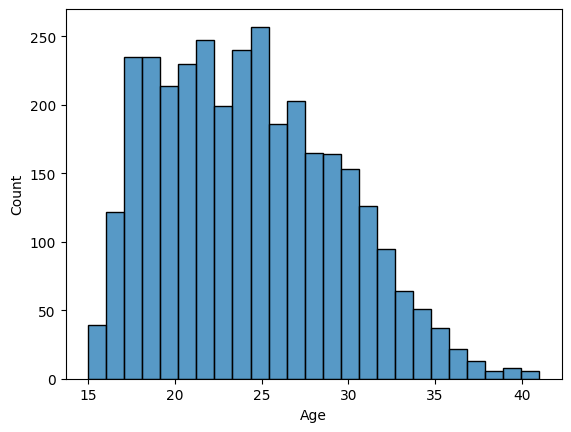

In [36]:
sns.histplot(stats['Age']);

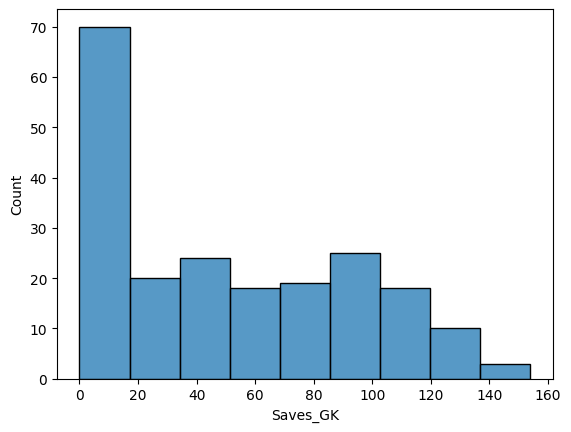

In [37]:
sns.histplot(stats['Saves_GK']);

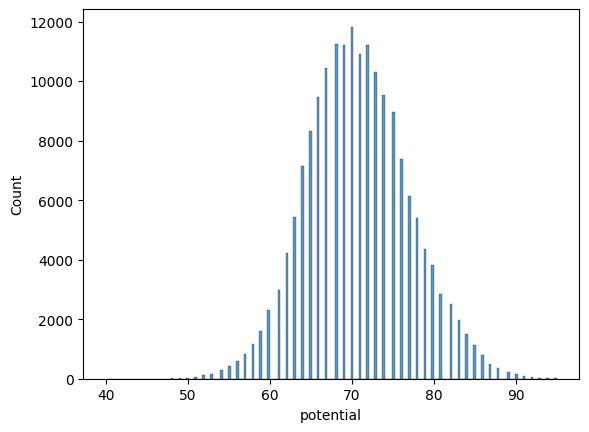

In [38]:
sns.histplot(ea_sports['potential']);

### Cleaning + Preprocessing

##### Drop Unnecessary Columns and Rows

In [39]:
ea_columns_to_drop = ['player_id', 'player_url', 'fifa_version', 'fifa_update', 'league_id', 
                    'league_level', 'club_team_id', 'club_position', 'club_loaned_from', 'nationality_id', 'nation_team_id','nation_position', 
                    'nation_jersey_number', 'international_reputation', 'body_type', 'real_face', 'pace', 'shooting', 'passing', 
                    'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 
                    'attacking_short_passing', 'attacking_volleys', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 
                    'power_shot_power', 'power_long_shots','mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 
                    'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking_awareness', 
                    'defending_standing_tackle', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 
                    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 
                    'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'
                  ]

stats_columns_to_drop = ['Comp', 'Pos', 'Age', 'Born', 'MP', 'Minutes_Played', 'Mn_per_MP', 'PPM_Team.Success', 
                         'onG_Team.Success', 'onGA_Team.Success', 'plus_per__minus__Team.Success', 'NonPKG', 'PK', 'PKatt', 
                         'npxG+xAG', 'Gls_Per90', 'Ast_Per90', 'G+A_Per90', 'G_minus_PK_Per', 'G+A_minus_PK_Per', 'xG_Per', 
                         'xAG_Per', 'xG+xAG_Per', 'G_per_Sh', 'G_per_SoT', 'Avg_Shot_Dist', 'FK_Standard', 'G_minus_xG_Expected',
                         'np:G_minus_xG_Expected', 'Passes_Attempted', 'Passes_Cmp_Short', 'Passes_Att_Short', 
                         'Passes_Cmp_percent_Short', 'Passes_Cmp_Medium', 'Passes_Att_Medium', 'Passes_Cmp_percent_Medium', 
                         'Passes_Cmp_Long', 'Passes_Att_Long', 'Passes_Cmp_percent_Long', 'A_minus_xAG_Expected', 
                         'CrsPA', 'TB_Pass', 'Crs_Pass', 'Offside_Passes', 'Blocked_Passes', 
                         'SCA_90', 'TakeOnTo_Shot', 'FoulTo_Shot', 'FoulTo_Shot', 'GCA90', 'TakeOn_Goal', 'Fld_Goal', 'Lost_Challenges',
                         'Passes_Blocked', 'ErrorsLead_ToShot', 'Att_Take', 'Tkld_Take', 'Tkld_percent_Take', 
                         'TotDist_Carries', 'PrgDist_Carries', 'Miscontrolls', 'Dispossessed', '2CrdY','PK_Won', 
                         'PK_Conceded', 'Own_Goals', 'Loose_Ball_Recoveries', 'Lost_Aerial', 'SoT_Against_GK', 'PK_Faced_GK', 
                         'PK_Allowed_GK', 'PK_Saved_GK', 'PK_Missed_GK', 'Save_percent_Penalty_GK', 'FK_Goals_GK', 
                         'CornerKick_Goals_GK', 'OG_GK', 'PSxG_GK', 'PSxG_per_SoT_GK', 'PSxG+_per_minus_GK', 'Cmp_percent_Launched_GK', 
                         'Att_Passes_GK', 'Throws_GK', 'Launch_percent_Passes_GK', 'AvgLen_Passes_GK', 'Att_Goal_Kicks_GK', 'AvgLen_GoalKick_GK', 
                         'CrossesFaced_GK', 'CrossedStopped_Perc_GK', 'OPA_Sweeper_GK', 'OPA_per_90_Sweeper_GK', 'AvgDist_Sweeper_GK'
                        ]

# Define the list of leagues
top_leagues = ['Ligue 1', 'Premier League', 'La Liga', 'Bundesliga', 'Serie A']


In [40]:
# Filter the ea_sports dataset for FIFA23
ea_sports = ea_sports[ea_sports['fifa_version'] == 23]

In [41]:
# Filter the ea_sports dataset for top leagues
ea_sports = ea_sports[ea_sports['league_name'].isin(top_leagues)]

In [42]:
ea_sports.shape

(3562, 109)

In [43]:
# Drop unnecessary columns from ea_sports dataset
ea_sports.drop(columns=ea_columns_to_drop, inplace=True)

In [44]:
# Drop unnecessary columns from stats dataset
stats.drop(columns=stats_columns_to_drop, inplace=True)

##### Fill NaN values with 0

In [52]:
float_cols_stats = stats.select_dtypes(include='float64').columns
stats[float_cols_stats] = stats[float_cols_stats].fillna(0)

In [51]:
float_cols_ea = ea_sports.select_dtypes(include='float64').columns
ea_sports[float_cols_ea] = ea_sports[float_cols_ea].fillna(0)

##### Split 'player_position' column

In [53]:
ea_sports['player_positions'] = ea_sports['player_positions'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else x)

##### Change Data type

In [54]:
# List of columns to convert
stats_columns_to_convert = ['Starts', 'Goals', 'Assists', 'GoalsAssistsCombined', 'CrdY', 'CrdR', 'PrgC', 'PrgP', 'Shots', 
                      'Shots_on_Target', 'Passes_Completed', 'PrgDist_Total', 'Key_Passes', 'Final_Third', 'PPA', 'Shot_Creating_Actions',
                      'DefAction_Shot', 'GoalCreatingAction', 'DefAction_Goal', 'Tackles', 'Tackles_Won', 'Def_3rd_Tackles', 
                      'Mid_3rd_Tackles', 'Att_3rd_Tackles', 'Blocks', 'Sh_Blocked', 'Interceptions', 'Clearances', 'Succ_Take',
                      'Fouls_Comitted', 'Fouls_Drawn', 'Offsides', 'Crosses', 'Won_Aerial', 'Goals_Against_GK', 'Saves_GK', 
                      'Clean_Sheets_GK', 'LaunchedPassesCompleted_GK', 'LaunchedAttempted_GK', 'CrossedStopped_GK'
                     ]
ea_columns_to_convert = ['club_jersey_number', 'club_contract_valid_until_year']

In [55]:
# Convert columns from float to int
stats[stats_columns_to_convert] = stats[stats_columns_to_convert].astype('int')
ea_sports[ea_columns_to_convert] = ea_sports[ea_columns_to_convert].astype('int')

##### Check for Duplicates

In [56]:
# Remove duplicates based on specific columns
stats = stats.drop_duplicates(subset=['Player', 'Starts'])

In [57]:
# Check for duplicates 'Player' column
duplicates_in_stats = stats.duplicated(subset=['Player', 'Starts'])

# Show rows that are duplicates in that column
stats[duplicates_in_stats]


,Squad,Player,Nation,Mins_Per_90,Starts,Goals,Assists,GoalsAssistsCombined,CrdY,CrdR,xG,xAG,PrgC,PrgP,Shots,Shots_on_Target,SoT_percent,Passes_Completed,Passes_Cmp_percent,PrgDist_Total,xA_Expected,Key_Passes,Final_Third,PPA,Shot_Creating_Actions,DefAction_Shot,GoalCreatingAction,DefAction_Goal,Tackles,Tackles_Won,Def_3rd_Tackles,Mid_3rd_Tackles,Att_3rd_Tackles,Tkl_percent_won,Blocks,Sh_Blocked,Interceptions,Clearances,Succ_Take,Succ_percent_Take,Fouls_Comitted,Fouls_Drawn,Offsides,Crosses,Won_Aerial,Won_percent_Aerial,Goals_Against_GK,Saves_GK,Save_percent_GK,Clean_Sheets_GK,CS_percent_GK,LaunchedPassesCompleted_GK,LaunchedAttempted_GK,CrossedStopped_GK


In [58]:
# Check for duplicates in 'long_name' column
duplicates_in_ea = ea_sports.duplicated(subset=['long_name', 'height_cm'], keep=False)

# Show rows that are duplicates in that column
ea_sports[duplicates_in_ea]

,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_name,league_name,club_jersey_number,club_joined_date,club_contract_valid_until_year,nationality_name,preferred_foot,weak_foot,skill_moves,work_rate,release_clause_eur,player_tags,player_traits,skill_dribbling,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_jumping,power_stamina,power_strength,defending_sliding_tackle,goalkeeping_diving,goalkeeping_reflexes,goalkeeping_speed


##### Rename Stats Columns

In [59]:
# Assuming your DataFrame is named 'df'
stats.rename(columns={
    'Player': 'player',
    'Nation': 'nation',
    'Mins_Per_90': 'mins_per_90',
    'Starts': 'starts',
    'Goals': 'goals',
    'Assists': 'assists',
    'GoalsAssistsCombined': 'g+a_combined',
    'CrdY': 'yellow_cards',
    'CrdR': 'red_cards',
    'xG': 'expected_goals',
    'xAG': 'expected_g+a',
    'PrgC': 'prog_carries',
    'PrgP': 'prog_passes',
    'Shots': 'shots',
    'Shots_on_Target': 'shots_on_target',
    'SoT_percent': 'sot_percent',
    'Passes_Completed': 'passes_completed',
    'Passes_Cmp_percent': 'pass_completion_percent',
    'PrgDist_Total': 'prog_pass_dist',
    'xA_Expected': 'expected_assists',
    'Key_Passes': 'key_passes',
    'Final_Third': 'final_third_passes',
    'PPA': 'passes_pen_area',
    'Shot_Creating_Actions': 'shot_creating_actions',
    'DefAction_Shot': 'def_actions_to_shot',
    'GoalCreatingAction': 'goal_creating_actions',
    'DefAction_Goal': 'def_actions_to_goal',
    'Tackles': 'tackles',
    'Tackles_Won': 'tackles_won',
    'Def_3rd_Tackles': 'def_third_tackles',
    'Mid_3rd_Tackles': 'mid_third_tackles',
    'Att_3rd_Tackles': 'att_third_tackles',
    'Tkl_percent_won': 'tackle_win_percent',
    'Blocks': 'blocks',
    'Sh_Blocked': 'shots_blocked',
    'Interceptions': 'interceptions',
    'Clearances': 'clearances',
    'Succ_Take': 'take_ons',
    'Succ_percent_Take': 'take_on_success_percent',
    'Fouls_Comitted': 'fouls_committed',
    'Fouls_Drawn': 'fouls_drawn',
    'Offsides': 'offsides',
    'Crosses': 'crosses',
    'Won_Aerial': 'aerial_duels_won',
    'Won_percent_Aerial': 'aerial_win_percent',
    'Goals_Against_GK': 'goals_conceeded_gk',
    'Saves_GK': 'saves_gk',
    'Save_percent_GK': 'save_percent_gk',
    'Clean_Sheets_GK': 'clean_sheets_gk',
    'CS_percent_GK': 'clean_sheet_percent_gk',
    'LaunchedPassesCompleted_GK': 'launched_passes_completed_gk',
    'LaunchedAttempted_GK': 'launched_passes_attempted_gk',
    'CrossedStopped_GK': 'crosses_stopped_gk'
}, inplace=True)


##### Rename Club Names

In [60]:
club_renaming = {
    'Angers': 'Angers SCO',
    'Augsburg': 'FC Augsburg',
    'Bayern Munich': 'FC Bayern München',
    'Betis': 'Real Betis',
    'Bochum': 'VfL Bochum 1848',
    'Bournemouth': 'AFC Bournemouth',
    'Brighton': 'Brighton & Hove Albion',
    'Clermont Foot': 'Clermont',
    'Dortmund': 'Borussia Dortmund',
    'Eint Frankfurt': 'Eintracht Frankfurt',
    'Freiburg': 'SC Freiburg',
    'Hoffenheim': 'TSG Hoffenheim',
    'Köln': 'FC Köln',
    'Leverkusen': 'Bayer 04 Leverkusen',
    'Lyon': 'Olympique Lyonnais',
    "M'Gladbach": 'Borussia Mönchengladbach',
    'Mainz 05': '1. FSV Mainz 05',
    'Marseille': 'Olympique Marseille',
    'Paris S-G': 'Paris Saint Germain',
    'Stuttgart': 'VfB Stuttgart',
    'Tottenham': 'Tottenham Hotspur',
    'Valladolid': 'Real Valladolid',
    'West Ham': 'West Ham United',
    'Wolfsburg': 'VfL Wolfsburg',
    'Wolves': 'Wolverhampton Wanderers'
}

# Replace squad names in the 'Squad' column
stats['Squad'] = stats['Squad'].replace(club_renaming)

### Merging

In [61]:
# Copy original datasets to avoid modifying them directly
stats_df = stats.copy()
ea_sports_df = ea_sports.copy()

# Preprocess player names by converting to lowercase and stripping extra whitespace
stats_df['player_clean'] = stats_df['player'].str.lower().str.strip()
ea_sports_df['short_name_clean'] = ea_sports_df['short_name'].str.lower().str.strip()
ea_sports_df['long_name_clean'] = ea_sports_df['long_name'].str.lower().str.strip()

# Optionally, keep only the first and last names by removing middle names
stats_df['player_clean'] = stats_df['player_clean'].apply(lambda x: ' '.join(x.split()[:2]))
ea_sports_df['short_name_clean'] = ea_sports_df['short_name_clean'].apply(lambda x: ' '.join(x.split()[:2]))
ea_sports_df['long_name_clean'] = ea_sports_df['long_name_clean'].apply(lambda x: ' '.join(x.split()[:2]))

# Function to merge datasets on specified columns for exact matching
def exact_merge(left_df, right_df, right_on):
    return pd.merge(left_df, right_df, left_on=['player_clean', 'Squad'], right_on=right_on, how='inner')

# Function to find the best fuzzy match for a name with a specified threshold
def match_names(name, name_list, threshold=85):
    match = process.extractOne(name, name_list, scorer=fuzz.token_sort_ratio)
    if match and match[1] >= threshold:
        return match[0]  # Return the matched name if score meets threshold
    else:
        return None

# Perform exact merge based on short and long names with club names
short_merge_df = exact_merge(stats_df, ea_sports_df, ['short_name_clean', 'club_name'])
long_merge_df = exact_merge(stats_df, ea_sports_df, ['long_name_clean', 'club_name'])

# Create fuzzy-matched names and clubs in stats_df for additional merging
stats_df['fuzzy_matched_name'] = stats_df['player_clean'].apply(lambda x: match_names(x, ea_sports_df['short_name_clean'].tolist()))
stats_df['fuzzy_matched_club'] = stats_df['Squad'].apply(lambda x: match_names(x, ea_sports_df['club_name'].tolist()))

# Create a copy of stats_df for long name matching
long_stats_df = stats_df.copy()
long_stats_df['fuzzy_matched_name'] = long_stats_df['player_clean'].apply(lambda x: match_names(x, ea_sports_df['long_name_clean'].tolist()))
long_stats_df['fuzzy_matched_club'] = long_stats_df['Squad'].apply(lambda x: match_names(x, ea_sports_df['club_name'].tolist()))

# Merge on fuzzy-matched names and clubs
short_merge_df = pd.merge(stats_df, ea_sports_df, left_on=['fuzzy_matched_name', 'fuzzy_matched_club'], right_on=['short_name_clean', 'club_name'], how='inner')
long_merge_df = pd.merge(long_stats_df, ea_sports_df, left_on=['fuzzy_matched_name', 'fuzzy_matched_club'], right_on=['long_name_clean', 'club_name'], how='inner')

# Concatenate results from exact and fuzzy merges, then drop duplicates
df = pd.concat([short_merge_df, long_merge_df], axis=0).reset_index(drop=True)
df = df.drop_duplicates(subset=['player', 'height_cm', 'club_name', 'long_name'])

# Display the head of the final dataframe
df.head()


,Squad,player,nation,mins_per_90,starts,goals,assists,g+a_combined,yellow_cards,red_cards,expected_goals,expected_g+a,prog_carries,prog_passes,shots,shots_on_target,sot_percent,passes_completed,pass_completion_percent,prog_pass_dist,expected_assists,key_passes,final_third_passes,passes_pen_area,shot_creating_actions,def_actions_to_shot,goal_creating_actions,def_actions_to_goal,tackles,tackles_won,def_third_tackles,mid_third_tackles,att_third_tackles,tackle_win_percent,blocks,shots_blocked,interceptions,clearances,take_ons,take_on_success_percent,fouls_committed,fouls_drawn,offsides,crosses,aerial_duels_won,aerial_win_percent,goals_conceeded_gk,saves_gk,save_percent_gk,clean_sheets_gk,clean_sheet_percent_gk,launched_passes_completed_gk,launched_passes_attempted_gk,crosses_stopped_gk,player_clean,fuzzy_matched_name,fuzzy_matched_club,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_name,league_name,club_jersey_number,club_joined_date,club_contract_valid_until_year,nationality_name,preferred_foot,weak_foot,skill_moves,work_rate,release_clause_eur,player_tags,player_traits,skill_dribbling,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_jumping,power_stamina,power_strength,defending_sliding_tackle,goalkeeping_diving,goalkeeping_reflexes,goalkeeping_speed,short_name_clean,long_name_clean
0,Almería,Léo Baptistão,BRA,19.2,24,5,1,6,7,0,4.9,1.2,38,51,45,16,35.6,359,66.5,1514,0.9,18,30,13,53,2,3,0,32,20,13,16,3,39.4,17,2,19,12,14,38.9,30,23,10,18,27,40.3,0,0,0.0,0,0.0,0,0,0,léo baptistão,léo baptistão,Almería,2022-09-26,Léo Baptistão,Leonardo Carrilho Baptistão,ST,76,76,7500000.0,28000.0,29,1992-08-26,181,71,Almería,La Liga,12,2022-08-11,2026,Brazil,Right,2,4,Medium/Medium,16500000.0,NaN,NaN,76,78,76,81,79,81,75,81,78,71,19,8,9,0.0,léo baptistão,leonardo carrilho
1,Almería,Álex Centelles,ESP,12.5,11,1,2,3,0,1,0.4,1.3,17,35,5,2,40.0,412,71.4,2965,1.1,13,32,9,24,0,4,0,22,14,16,3,3,72.7,13,2,11,40,6,42.9,7,5,0,46,7,29.2,0,0,0.0,0,0.0,0,0,0,álex centelles,álex centelles,Almería,2022-09-26,Álex Centelles,Alejandro Centelles Plaza,LB,74,81,8000000.0,17000.0,22,1999-08-30,185,73,Almería,La Liga,20,2020-10-02,2026,Spain,Left,3,3,Medium/Medium,19200000.0,NaN,Early Crosser,70,75,76,79,66,74,55,61,86,72,68,14,8,0.0,álex centelles,alejandro centelles
2,Almería,Samu Costa,POR,22.1,22,1,2,3,5,0,1.7,1.0,9,91,20,7,35.0,864,78.8,5134,1.0,13,68,11,47,3,3,0,61,31,35,20,6,47.5,29,7,37,64,9,40.9,51,44,4,8,48,66.7,0,0,0.0,0,0.0,0,0,0,samu costa,samú costa,Almería,2022-09-26,Samú Costa,Samuel de Almeida Costa,CDM,72,81,5000000.0,12000.0,21,2000-11-27,183,75,Almería,La Liga,23,2021-07-01,2026,Portugal,Left,2,2,Medium/Medium,12000000.0,NaN,"Long Passer (AI), Long Shot Taker (AI), Playma...",66,69,68,61,68,69,64,68,76,72,70,6,9,0.0,samú costa,samuel de
3,Almería,Rodrigo Ely,BRA,35.1,36,0,1,1,10,1,1.0,0.8,6,52,19,1,5.3,1197,81.2,10151,0.6,6,54,3,21,0,2,0,30,21,26,4,0,72.0,46,33,31,203,5,71.4,25,14,2,3,79,67.5,0,0,0.0,0,0.0,0,0,0,rodrigo ely,rodrigo ely,Almería,2022-09-26,Rodrigo Ely,Rodrigo Ely,CB,75,75,4800000.0,23000.0,28,1993-11-03,188,83,Almería,La Liga,19,2022-03-07,2024,Brazil,Right,2,2,Medium/High,10600000.0,#Strength,"Injury Prone, Power Header",50,59,44,51,46,71,31,74,34,90,75,13,11,0.0,rodrigo ely,rodrigo ely
4,Almería,Fernando,ESP,36.5,37,0,0,0,3,0,0.0,0.0,0,0,0,0,0.0,919,70.0,20366,0.0,0,16,0,4,0,0,0,0,0,0,0,0,0.0,2,0,1,20,1,100.0,0,6,0,0,2,66.7,61,132,70.5,4,10.8,199,557,39,fernando,fernando,Almería,2022-09-26,Fernando,Fernando Martínez Rubio,GK,75,75,2800000.0,18000.0,32,1990-06-10,185,85,Almería,La Liga,13,2017-07-05,2023,Spain,Right,2,1,Medium/Medium,6200000.0,NaN,GK Long Throw,14,23,48,47,43,74,56,72,30,64,19,75,76,48.0,fernando,fernando martínez


In [62]:
columns_to_drop = ['Squad', 'player', 'nation', 'player_clean', 'fuzzy_matched_name', 
                   'fuzzy_matched_club', 'short_name_clean', 'long_name_clean'
                  ]
# Drop unnecessary columns from ea_sports dataset
df.drop(columns=columns_to_drop, inplace=True)

In [63]:
# Define the new column order
column_order = [
    # Player Identifiers and Information
    'short_name', 'long_name', 'dob', 'age', 'height_cm', 'weight_kg', 'nationality_name', 
    'league_name', 'club_name', 'player_positions', 'club_jersey_number', 'club_joined_date', 'club_contract_valid_until_year',

    # Financial Attributes
    'value_eur', 'wage_eur', 'release_clause_eur',

    # Physical and Skill Attributes
    'preferred_foot', 'weak_foot', 'skill_moves', 'work_rate', 'skill_dribbling', 'skill_ball_control', 
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_jumping', 'power_stamina', 'power_strength', 'defending_sliding_tackle', 'potential', 'overall',

    # Goalkeeping Attributes
    'goalkeeping_diving', 'goalkeeping_reflexes', 'goalkeeping_speed', 'goals_conceeded_gk', 'saves_gk', 'save_percent_gk', 
    'clean_sheets_gk', 'clean_sheet_percent_gk', 'launched_passes_completed_gk', 'launched_passes_attempted_gk', 'crosses_stopped_gk',

    # Performance Stats
    'mins_per_90', 'starts', 'goals', 'assists', 'g+a_combined', 'yellow_cards', 'red_cards', 'expected_goals', 
    'expected_g+a', 'prog_carries', 'prog_passes', 'shots', 'shots_on_target', 'sot_percent', 'passes_completed', 
    'pass_completion_percent', 'prog_pass_dist', 'expected_assists', 'key_passes', 'final_third_passes', 'shot_creating_actions',
    'passes_pen_area', 'def_actions_to_shot', 'goal_creating_actions', 'def_actions_to_goal',

    # Defensive Stats
    'tackles', 'tackles_won', 'def_third_tackles', 'mid_third_tackles', 'att_third_tackles', 'tackle_win_percent', 
    'blocks', 'shots_blocked', 'interceptions', 'clearances',

    # Other Actions and Miscellaneous Stats
    'take_ons', 'take_on_success_percent', 'fouls_committed', 'fouls_drawn', 'offsides', 'crosses', 'aerial_duels_won', 'aerial_win_percent',

    # Additional Player Traits
    'player_tags', 'player_traits'
]

# Reorder the DataFrame columns
df = df[column_order]


In [64]:
df.shape

(1657, 89)

## Feature Engineering

##### Performance Metrics

In [65]:
df['goal_contribution_per_90'] = (df['goals'] + df['assists']) / df['mins_per_90']

In [66]:
df['defensive_efficiency'] = (df['tackles'] + df['interceptions'] + df['blocks']) / df['mins_per_90']

In [67]:
df['goal_efficiency'] = df['goals'] / df['expected_goals']

In [68]:
df['assist_efficiency'] = df['assists'] / df['expected_assists']

##### Potential vs. Performance Differentials

In [69]:
df['performance_gap'] = df['overall'] - df['potential']

In [70]:
df['is_under_23'] = df['age'] < 23

##### Position-Specific Metrics

In [71]:
df['save_percentage'] = df['saves_gk'] / (df['saves_gk'] + df['goals_conceeded_gk'])
df['clean_sheet_ratio'] = df['clean_sheets_gk'] / df['starts']

##### Feature Interactions and Ratios

In [72]:
df['performance_efficiency'] = (
    df['goal_contribution_per_90'] +
    df['defensive_efficiency'] +
    df['goal_efficiency'] +
    df['assist_efficiency']
)

In [73]:
df.head()

,short_name,long_name,dob,age,height_cm,weight_kg,nationality_name,league_name,club_name,player_positions,club_jersey_number,club_joined_date,club_contract_valid_until_year,value_eur,wage_eur,release_clause_eur,preferred_foot,weak_foot,skill_moves,work_rate,skill_dribbling,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_jumping,power_stamina,power_strength,defending_sliding_tackle,potential,overall,goalkeeping_diving,goalkeeping_reflexes,goalkeeping_speed,goals_conceeded_gk,saves_gk,save_percent_gk,clean_sheets_gk,clean_sheet_percent_gk,launched_passes_completed_gk,launched_passes_attempted_gk,crosses_stopped_gk,mins_per_90,starts,goals,assists,g+a_combined,yellow_cards,red_cards,expected_goals,expected_g+a,prog_carries,prog_passes,shots,shots_on_target,sot_percent,passes_completed,pass_completion_percent,prog_pass_dist,expected_assists,key_passes,final_third_passes,shot_creating_actions,passes_pen_area,def_actions_to_shot,goal_creating_actions,def_actions_to_goal,tackles,tackles_won,def_third_tackles,mid_third_tackles,att_third_tackles,tackle_win_percent,blocks,shots_blocked,interceptions,clearances,take_ons,take_on_success_percent,fouls_committed,fouls_drawn,offsides,crosses,aerial_duels_won,aerial_win_percent,player_tags,player_traits,goal_contribution_per_90,defensive_efficiency,goal_efficiency,assist_efficiency,performance_gap,is_under_23,save_percentage,clean_sheet_ratio,performance_efficiency
0,Léo Baptistão,Leonardo Carrilho Baptistão,1992-08-26,29,181,71,Brazil,La Liga,Almería,ST,12,2022-08-11,2026,7500000.0,28000.0,16500000.0,Right,2,4,Medium/Medium,76,78,76,81,79,81,75,81,78,71,19,76,76,8,9,0.0,0,0,0.0,0,0.0,0,0,0,19.2,24,5,1,6,7,0,4.9,1.2,38,51,45,16,35.6,359,66.5,1514,0.9,18,30,53,13,2,3,0,32,20,13,16,3,39.4,17,2,19,12,14,38.9,30,23,10,18,27,40.3,NaN,NaN,0.312500,3.541667,1.020408,1.111111,0,False,NaN,0.000000,5.985686
1,Álex Centelles,Alejandro Centelles Plaza,1999-08-30,22,185,73,Spain,La Liga,Almería,LB,20,2020-10-02,2026,8000000.0,17000.0,19200000.0,Left,3,3,Medium/Medium,70,75,76,79,66,74,55,61,86,72,68,81,74,14,8,0.0,0,0,0.0,0,0.0,0,0,0,12.5,11,1,2,3,0,1,0.4,1.3,17,35,5,2,40.0,412,71.4,2965,1.1,13,32,24,9,0,4,0,22,14,16,3,3,72.7,13,2,11,40,6,42.9,7,5,0,46,7,29.2,NaN,Early Crosser,0.240000,3.680000,2.500000,1.818182,-7,True,NaN,0.000000,8.238182
2,Samú Costa,Samuel de Almeida Costa,2000-11-27,21,183,75,Portugal,La Liga,Almería,CDM,23,2021-07-01,2026,5000000.0,12000.0,12000000.0,Left,2,2,Medium/Medium,66,69,68,61,68,69,64,68,76,72,70,81,72,6,9,0.0,0,0,0.0,0,0.0,0,0,0,22.1,22,1,2,3,5,0,1.7,1.0,9,91,20,7,35.0,864,78.8,5134,1.0,13,68,47,11,3,3,0,61,31,35,20,6,47.5,29,7,37,64,9,40.9,51,44,4,8,48,66.7,NaN,"Long Passer (AI), Long Shot Taker (AI), Playma...",0.135747,5.746606,0.588235,2.000000,-9,True,NaN,0.000000,8.470588
3,Rodrigo Ely,Rodrigo Ely,1993-11-03,28,188,83,Brazil,La Liga,Almería,CB,19,2022-03-07,2024,4800000.0,23000.0,10600000.0,Right,2,2,Medium/High,50,59,44,51,46,71,31,74,34,90,75,75,75,13,11,0.0,0,0,0.0,0,0.0,0,0,0,35.1,36,0,1,1,10,1,1.0,0.8,6,52,19,1,5.3,1197,81.2,10151,0.6,6,54,21,3,0,2,0,30,21,26,4,0,72.0,46,33,31,203,5,71.4,25,14,2,3,79,67.5,#Strength,"Injury Prone, Power Header",0.028490,3.048433,0.000000,1.666667,0,False,NaN,0.000000,4.743590
4,Fernando,Fernando Martínez Rubio,1990-06-10,32,185,85,Spain,La Liga,Almería,GK,13,2017-07-05,2023,2800000.0,18000.0,6200000.0,Right,2,1,Medium/Medium,14,23,48,47,43,74,56,72,30,64,19,75,75,75,76,48.0,61,132,70.5,4,10.8,199,557,39,36.5,37,0,0,0,3,0,0.0,0.0,0,0,0,0,0.0,919,70.0,20366,0.0,0,16,4,0,0,0,0,0,0,0,0,0,0.0,2,0,1,20,1,100.0,0,6,0,0,2,66.7,NaN,GK Long Throw,0.000000,0.082192,NaN,NaN,0,False,0.683938,0.108108,NaN


## Analysis

##### Basic Descriptive Analysis

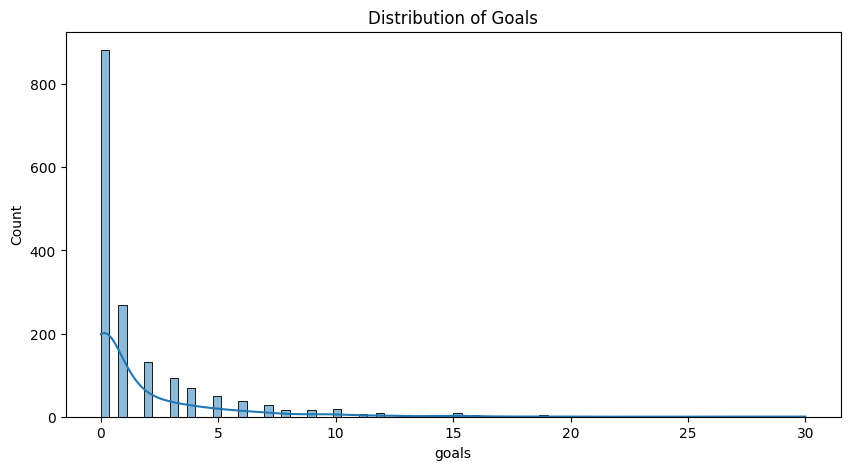

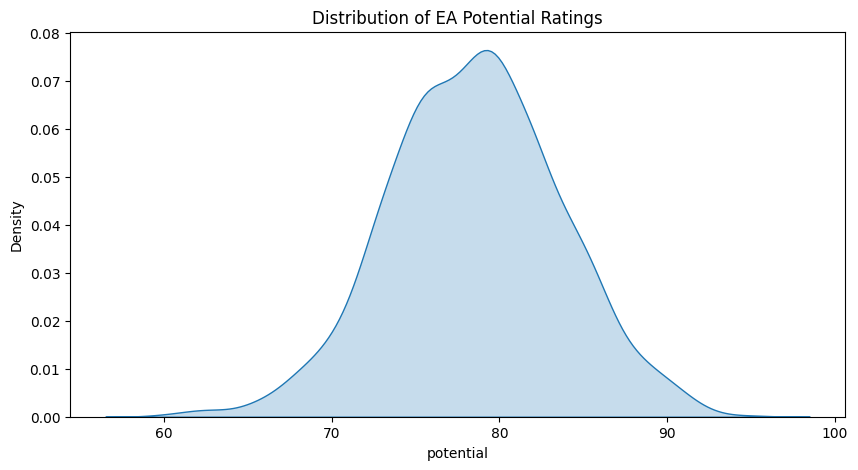

In [74]:
# Histogram for Goals
plt.figure(figsize=(10, 5))
sns.histplot(df['goals'], kde=True)
plt.title("Distribution of Goals")
plt.show()

# KDE Plot for Potential Ratings
plt.figure(figsize=(10, 5))
sns.kdeplot(df['potential'], fill=True)
plt.title("Distribution of EA Potential Ratings")
plt.show()


##### Comparing Goals by Position

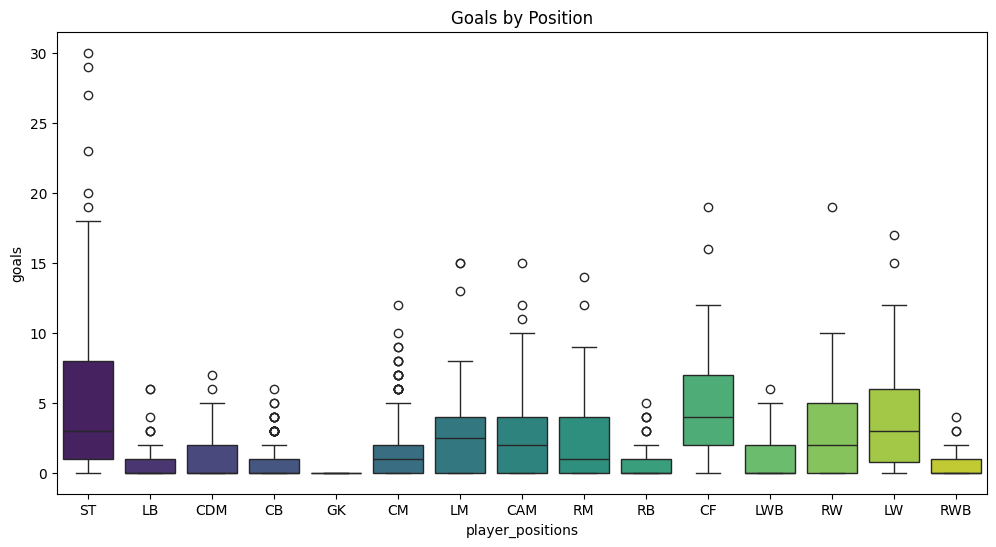

In [75]:
# Boxplot for Goals by Position
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='player_positions', y='goals', hue='player_positions', palette="viridis", dodge=False, legend=False)
plt.title("Goals by Position")
plt.show()

##### Segmenting Players by EA Potential Ratings

In [76]:
# Categorize players into 'High Potential' (85+) and 'Lower Potential'
df['potential_category'] = df['potential'].apply(lambda x: 'High Potential (85+)' if x >= 85 else 'Lower Potential (<85)')

# Composite Performance Index calculation
def calculate_position_performance(row):
    if row['player_positions'] in ['ST', 'LW', 'RW', 'CF']:  # Forward positions
        return (row['goals'] + row['assists'] + row['shots_on_target'])  # Goals + Assists
    elif row['player_positions'] in ['CM', 'CDM', 'CAM', 'RM', 'LM']:  # Midfielders
        return (row['assists'] + row['key_passes'] + row['prog_passes'])  # Assists + Key Passes
    elif row['player_positions'] in ['CB', 'LB', 'RB', 'LWB', 'RWB']:  # Defenders
        return (row['tackles'] + row['interceptions'] + row['blocks'])  # Tackles + Interceptions
    elif row['player_positions'] == 'GK':  # Goalkeepers
        return (row['saves_gk'] + row['clean_sheets_gk'])  # Saves
    else:
        return 0  # Default case

# Apply function to DataFrame
df['position_performance'] = df.apply(calculate_position_performance, axis=1)


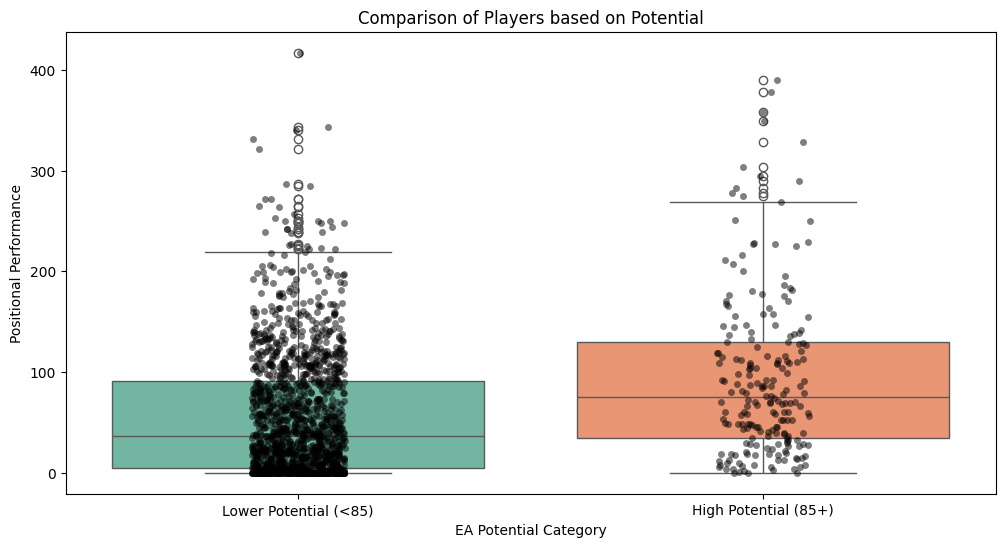

In [77]:
# Comparison of Players based on Potential

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='potential_category', y='position_performance', hue='potential_category', palette="Set2", dodge=False, legend=False)
sns.stripplot(data=df, x='potential_category', y='position_performance', color='black', alpha=0.5, jitter=True) # Overlay individual points

plt.title("Comparison of Players based on Potential")
plt.ylabel("Positional Performance")
plt.xlabel("EA Potential Category")
# Save the plot
plt.savefig("player_potential.png")
plt.show();


##### Identifying Overperformers and Underperformers

c:\Users\al3xd\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\regression.py:242: RuntimeWarning: invalid value encountered in dot
  return np.linalg.pinv(_x).dot(_y)
c:\Users\al3xd\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\regression.py:255: RuntimeWarning: invalid value encountered in dot
  yhat_boots = grid.dot(beta_boots).T
c:\Users\al3xd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


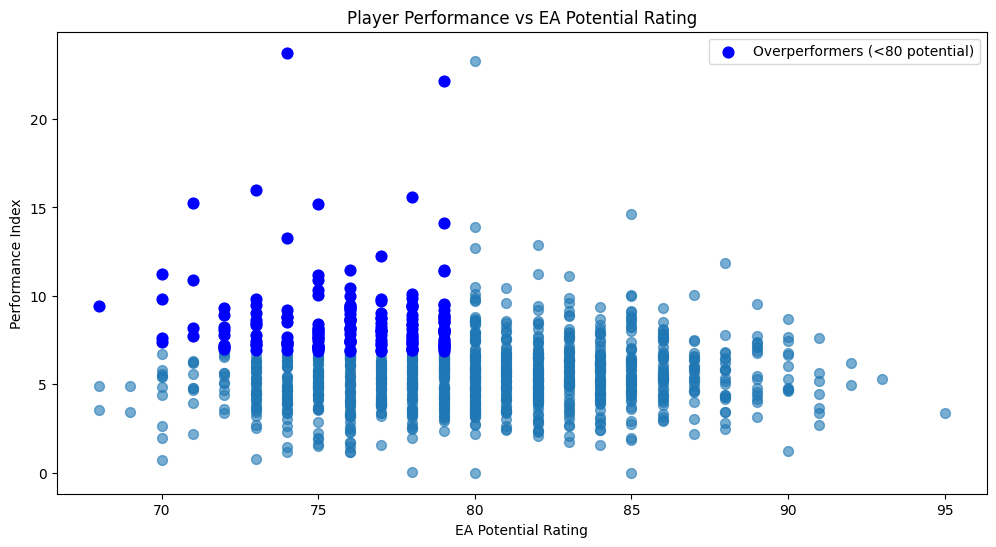

In [78]:
# Scatter Plot with a trendline
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='potential', y='performance_efficiency', scatter_kws={'s': 50, 'alpha': 0.6}, line_kws={'color': 'red'})

# Highlight players with potential < 80 and high performance index (above 75th percentile)
high_perf_threshold = df['performance_efficiency'].quantile(0.75)
highlighted = df[(df['potential'] < 80) & (df['performance_efficiency'] > high_perf_threshold)]
plt.scatter(highlighted['potential'], highlighted['performance_efficiency'], color='blue', s=60, label="Overperformers (<80 potential)")

plt.title("Player Performance vs EA Potential Rating")
plt.xlabel("EA Potential Rating")
plt.ylabel("Performance Index")
plt.legend()
plt.show()


##### Identifying Overperformers and Underperformers By Position

In [79]:
# Composite Performance Index calculation
def calculate_performance_index(row):
    if row['player_positions'] in ['ST', 'LW', 'RW', 'CF']:  # Forward positions
        return (row['goals'] + row['assists'] + row['shots_on_target']) / row['potential']  # Goals + Assists
    elif row['player_positions'] in ['CM', 'CDM', 'CAM', 'RM', 'LM']:  # Midfielders
        return (row['assists'] + row['key_passes']) / row['potential']  # Assists + Key Passes
    elif row['player_positions'] in ['CB', 'LB', 'RB', 'LWB', 'RWB']:  # Defenders
        return (row['tackles_won'] + row['interceptions']) / row['potential']  # Tackles + Interceptions
    elif row['player_positions'] == 'GK':  # Goalkeepers
        return ((row['saves_gk']  * 0.5) + row['clean_sheets_gk']) / row['potential']  # Saves
    else:
        return 0  # Default case

# Apply function to DataFrame
df['performance_index'] = df.apply(calculate_performance_index, axis=1)

# Calculate 25th and 75th percentiles
performance_25th = df['performance_index'].quantile(0.25)
performance_75th = df['performance_index'].quantile(0.75)

# Define Overperformers and Underperformers
overperformers = df[df['performance_index'] > 1.0]
underperformers = df[df['performance_index'] < 0.2]

In [80]:
# Overperformers

# Interactive Scatter Plot for Potential vs Goals
fig = px.scatter(overperformers, 
                 x='potential', 
                 y='performance_index', 
                 color='player_positions', 
                 hover_name='short_name',
                 title="Interactive Potential vs Performance Index Scatter Plot"
                )
fig.show()

In [81]:
# Underperformers

# Interactive Scatter Plot for Potential vs Goals
fig = px.scatter(underperformers, 
                 x='potential', 
                 y='performance_index', 
                 color='player_positions', 
                 hover_name='short_name', 
                 title="Interactive Potential vs Performance Index Scatter Plot"
                )
fig.show()

##### Age Group Analysis

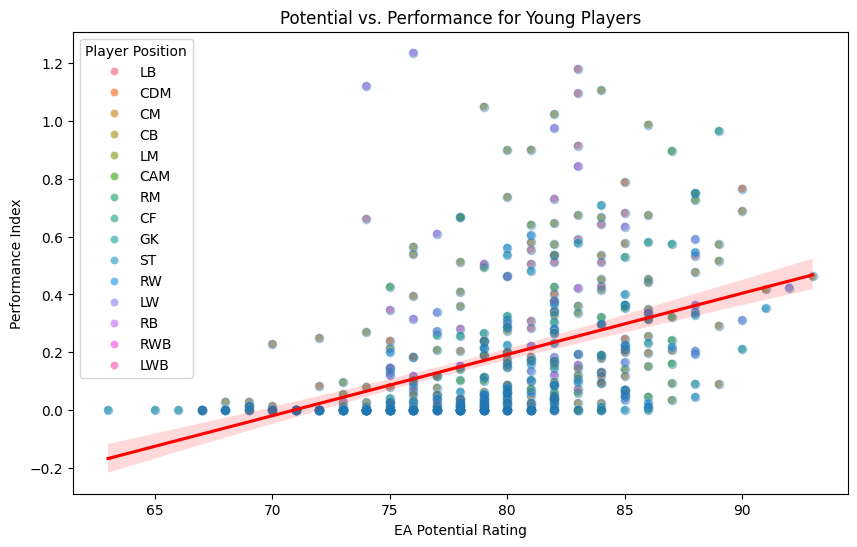

In [82]:
# Filter for young players
young_players = df[df['age'] < 23]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=young_players, x='potential', y='performance_index', hue='player_positions', alpha=0.7)

# Add trend line
sns.regplot(data=young_players, x='potential', y='performance_index', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})

plt.title('Potential vs. Performance for Young Players')
plt.xlabel('EA Potential Rating')
plt.ylabel('Performance Index')
plt.legend(title='Player Position')
plt.show()

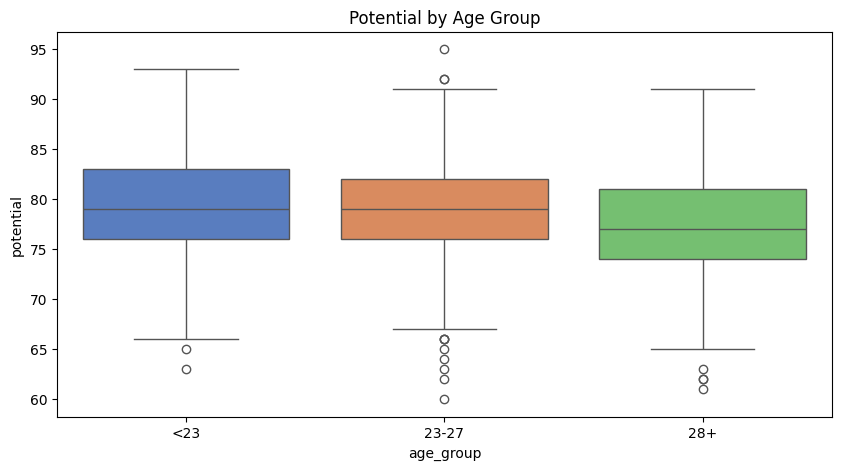

In [83]:
# Define Age Groups
df['age_group'] = pd.cut(df['age'], bins=[0, 22, 27, 100], labels=['<23', '23-27', '28+'])

# Potential by Age Group
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='age_group', y='potential', hue='age_group', palette="muted", dodge=False, legend=False)
plt.title("Potential by Age Group")
plt.show()

##### Positional Analysis

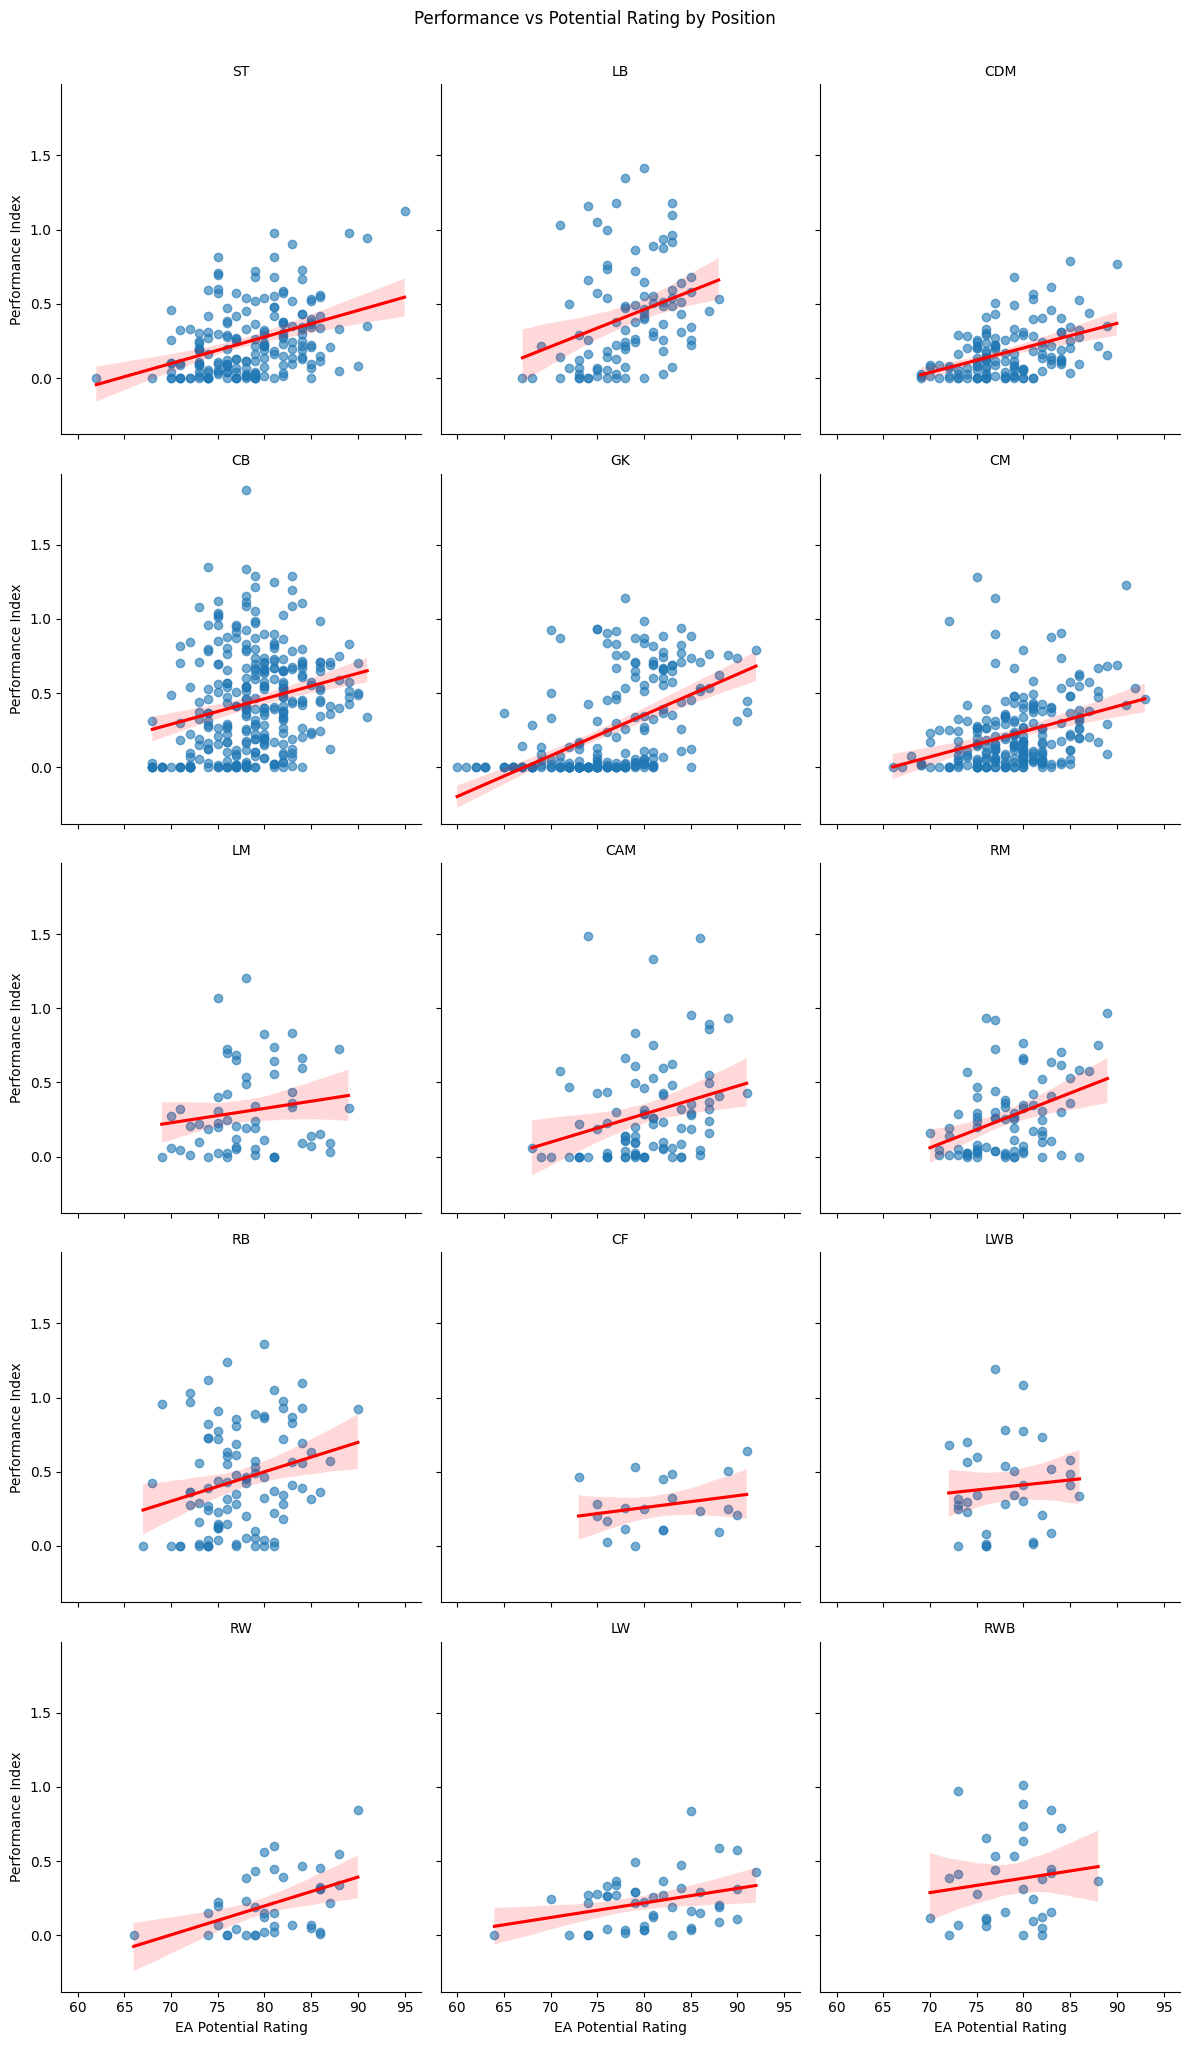

In [84]:
# Define a FacetGrid to split by position
g = sns.FacetGrid(df, col="player_positions", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.regplot, "potential", "performance_index", scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

g.set_axis_labels("EA Potential Rating", "Performance Index")
g.set_titles("{col_name}")
plt.suptitle("Performance vs Potential Rating by Position", y=1.02)
plt.show()


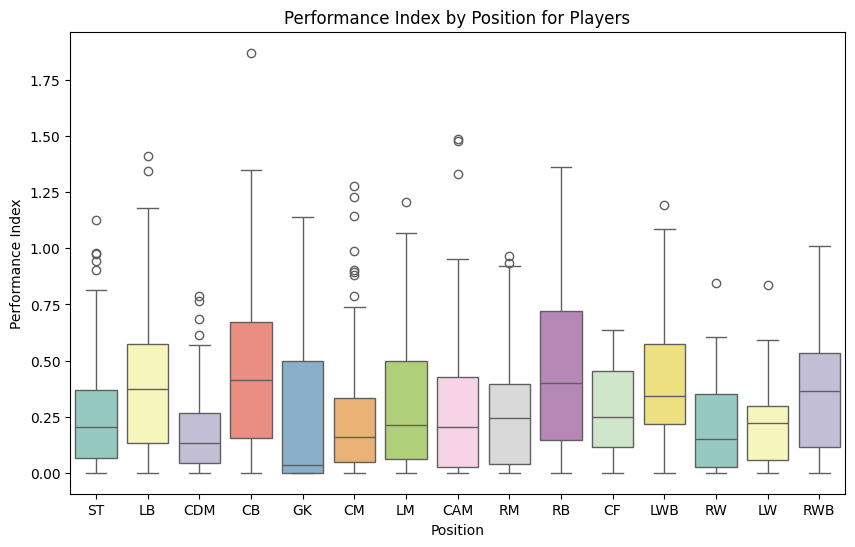

In [85]:
# Create box plot by position
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="player_positions", y="performance_index", hue='player_positions', palette="Set3", legend=False)

plt.title("Performance Index by Position for Players")
plt.xlabel("Position")
plt.ylabel("Performance Index")
plt.show()


##### League Performance Comparison

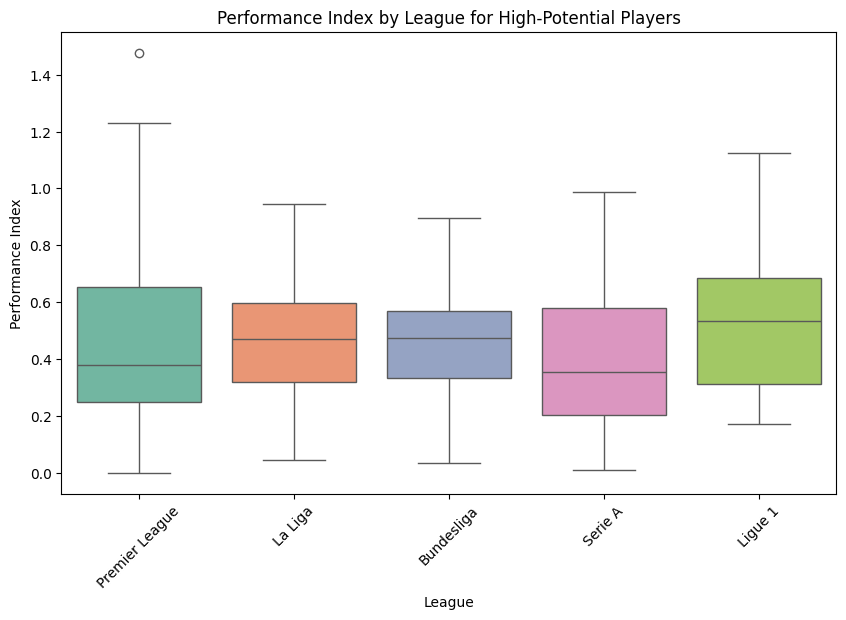

In [86]:
# Filter for high-potential players if desired
high_potential_players = df[df['potential'] > 85]

plt.figure(figsize=(10, 6))
sns.boxplot(data=high_potential_players, x="league_name", y="performance_index", hue='league_name', palette="Set2", legend=False)

plt.title("Performance Index by League for High-Potential Players")
plt.xlabel("League")
plt.ylabel("Performance Index")
plt.xticks(rotation=45)
plt.show()


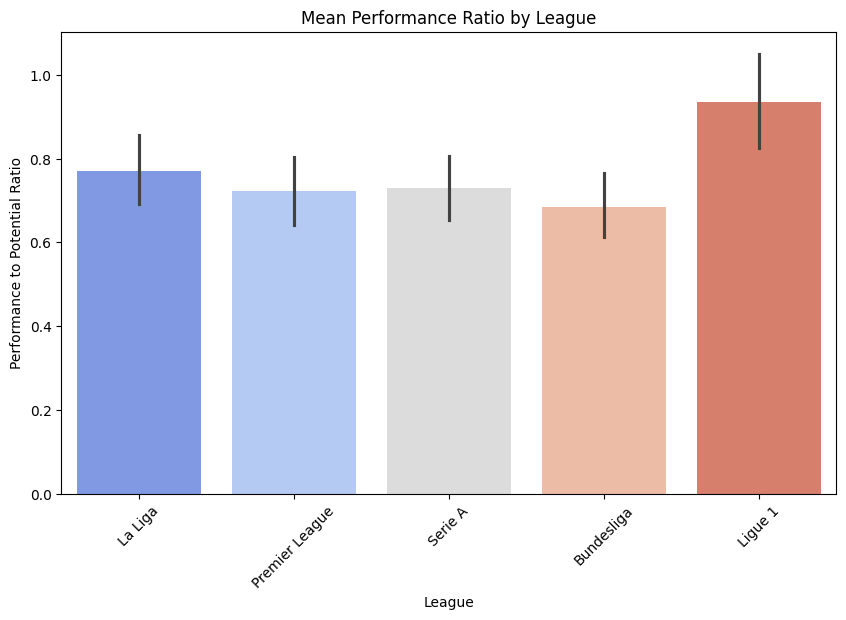

In [87]:
# Calculate performance ratio
df['performance_ratio'] = df['position_performance'] / df['potential']

# Plot the mean performance ratio by league
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="league_name", y="performance_ratio", hue='league_name', palette="coolwarm", legend=False)

plt.title("Mean Performance Ratio by League")
plt.xlabel("League")
plt.ylabel("Performance to Potential Ratio")
plt.xticks(rotation=45)
plt.show()


In [88]:
# Interactive Scatter Plot for Potential vs Goals
fig = px.scatter(overperformers, 
                 x='potential', 
                 y='performance_index', 
                 color='league_name', 
                 hover_name='short_name', 
                 title="Interactive Potential vs Performance Index Scatter Plot"
                )

fig.show()

In [89]:
# Interactive Scatter Plot for Potential vs Goals
fig = px.scatter(underperformers, 
                 x='potential', 
                 y='performance_index', 
                 color='league_name', 
                 hover_name='short_name', 
                 title="Interactive Potential vs Performance Index Scatter Plot"
                )
fig.show()

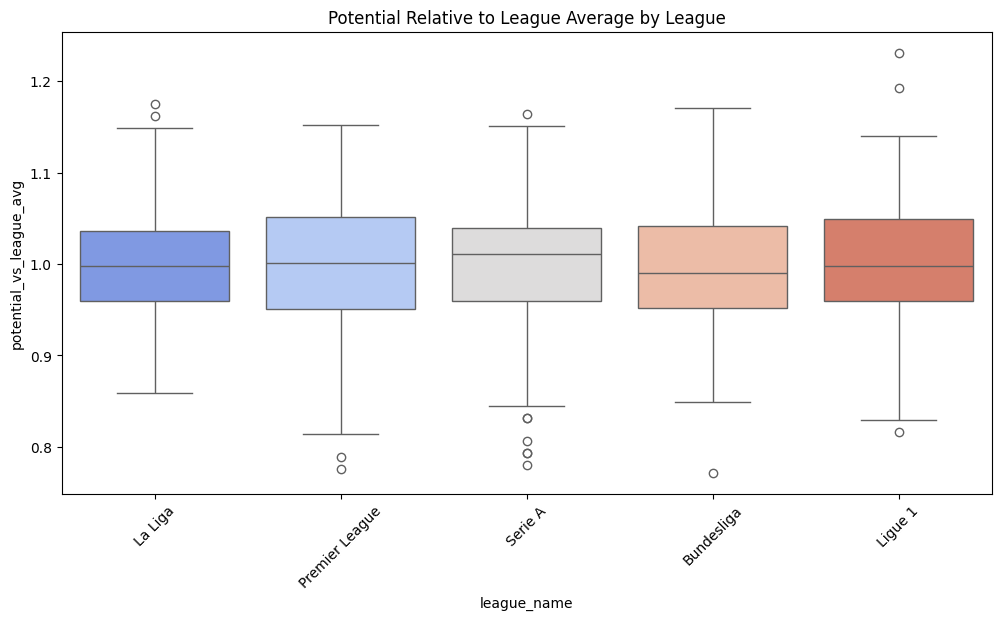

In [90]:
df_avg = df.copy()
# Calculate League Averages
league_avg = df_avg.groupby('league_name')['potential'].mean().reset_index()
df_avg = df_avg.merge(league_avg, on='league_name', suffixes=('', '_league_avg'))

# Goals vs League Average
df_avg['potential_vs_league_avg'] = df_avg['potential'] / df_avg['potential_league_avg']

# Visualize Goals vs League Average
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_avg, x='league_name', y='potential_vs_league_avg', hue='league_name', palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.title("Potential Relative to League Average by League")
plt.show()

##### Correlation Matrix


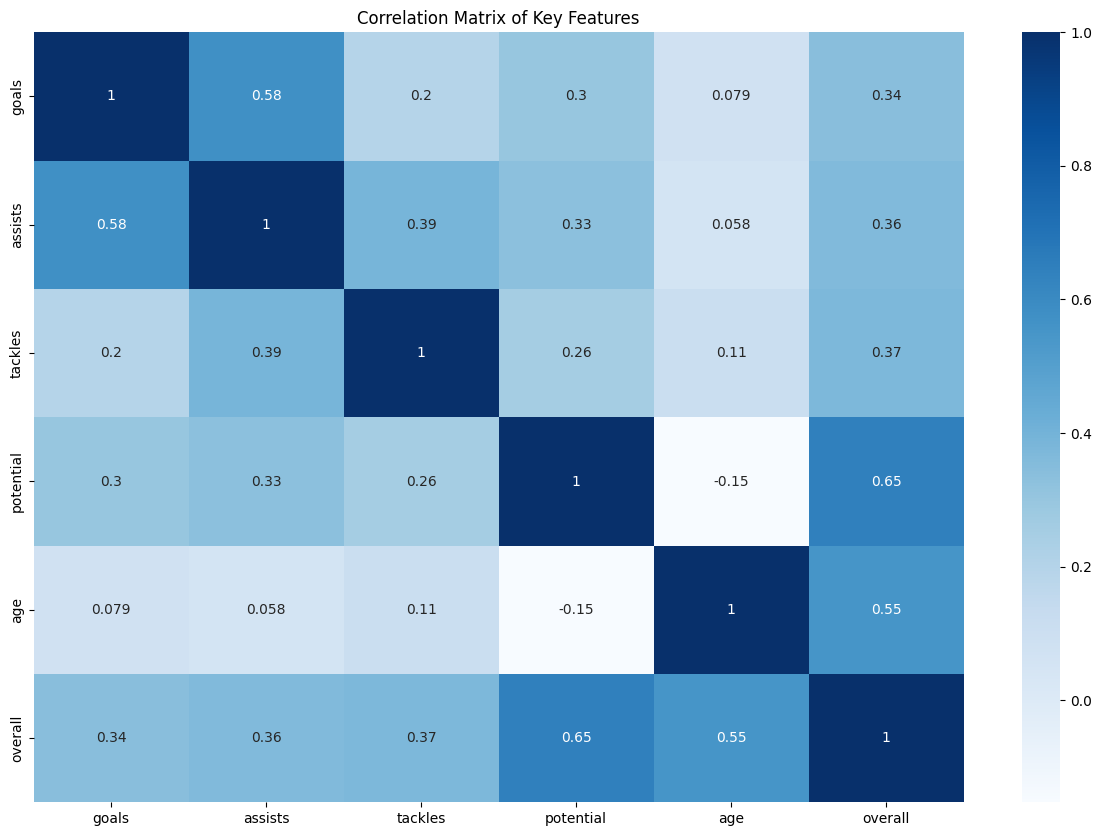

In [91]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df[['goals', 'assists', 'tackles', 'potential', 'age', 'overall']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix of Key Features")
plt.show()

##### Year of Contract End vs. Performance

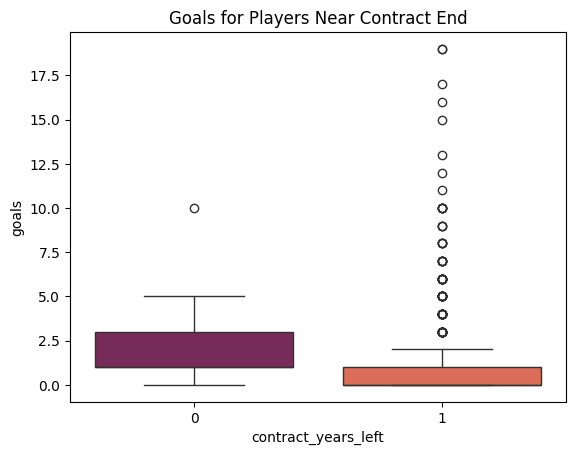

In [92]:
# Performance vs Contract Year for Players Near Contract End
df['contract_years_left'] = df['club_contract_valid_until_year'] - 2022
sns.boxplot(data=df[df['contract_years_left'] <= 1], x='contract_years_left', y='goals', hue='contract_years_left', palette="rocket", dodge=False, legend=False)
plt.title("Goals for Players Near Contract End")
plt.show()

##### Interactive Data Visualization 

In [93]:
# Interactive Scatter Plot for Potential vs Goals
fig = px.scatter(df, x='potential', y='goals', color='player_positions', hover_name='short_name', title="Interactive Potential vs Goals Scatter Plot")
fig.show()